ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: TATAMOTORS.NS"}}}
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['TATAMOTORS.NS']: YFTzMissingError('possibly delisted; no timezone found')


Assets: 45
Trading Days: 1730

Expected Annual Returns
Ticker
ADANIPORTS.NS    0.2750
ASIANPAINT.NS    0.1418
AXISBANK.NS      0.1607
BAJAJ-AUTO.NS    0.2436
BAJAJFINSV.NS    0.2234
BAJFINANCE.NS    0.2602
BEL.NS           0.4717
BHARTIARTL.NS    0.3345
CIPLA.NS         0.1963
COALINDIA.NS     0.2086
DRREDDY.NS       0.1661
EICHERMOT.NS     0.2246
GRASIM.NS        0.2292
HCLTECH.NS       0.2451
HDFCBANK.NS      0.1296
HDFCLIFE.NS      0.1419
HEROMOTOCO.NS    0.1684
HINDALCO.NS      0.2805
HINDUNILVR.NS    0.0784
ICICIBANK.NS     0.2394
INDUSINDBK.NS    0.0279
INFY.NS          0.1941
ITC.NS           0.1265
JSWSTEEL.NS      0.2671
KOTAKBANK.NS     0.1212
LT.NS            0.2049
M&M.NS           0.2906
MARUTI.NS        0.1685
NESTLEIND.NS     0.1607
NTPC.NS          0.2232
ONGC.NS          0.1960
POWERGRID.NS     0.2184
RELIANCE.NS      0.2066
SBILIFE.NS       0.2168
SBIN.NS          0.2348
SHRIRAMFIN.NS    0.3255
SUNPHARMA.NS     0.2443
TATACONSUM.NS    0.2957
TATASTEEL.NS     0.2782
TC

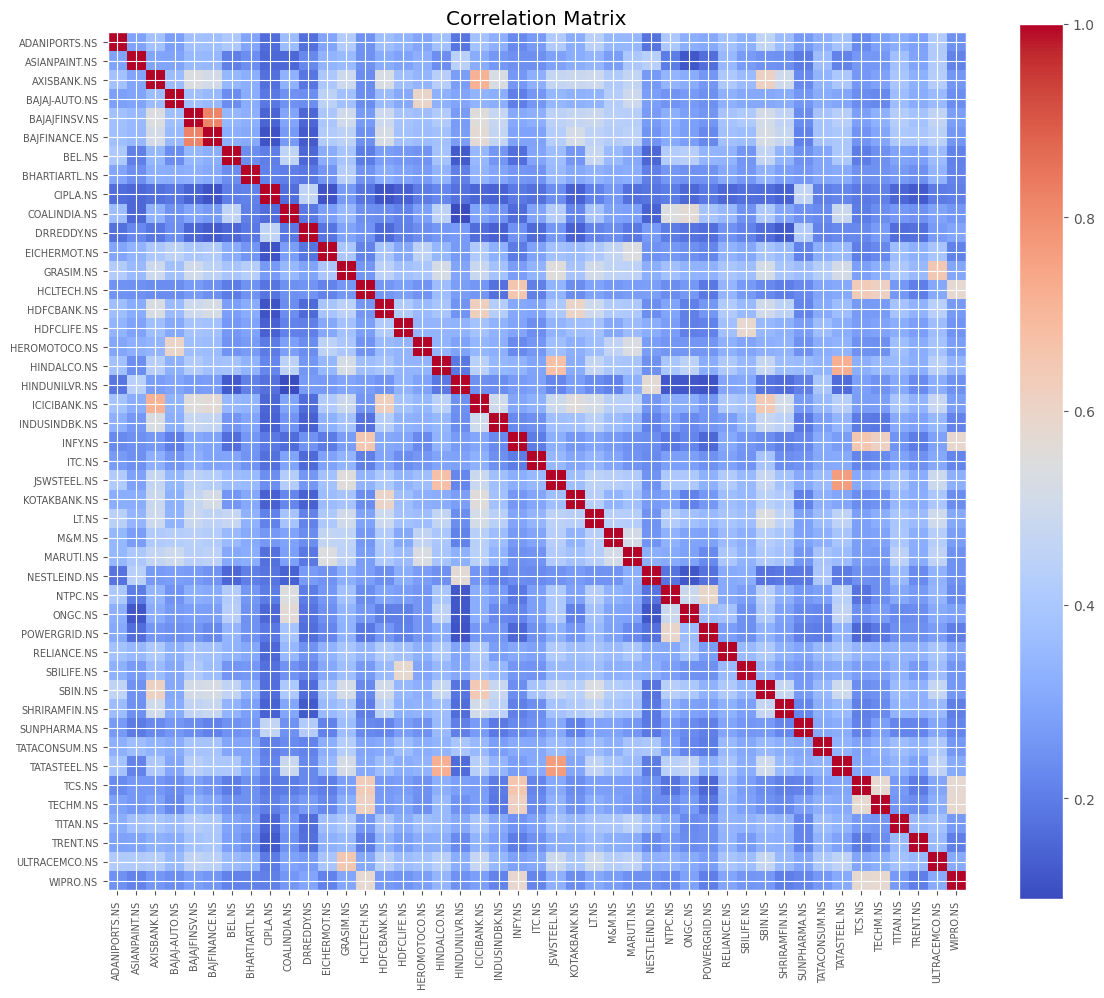

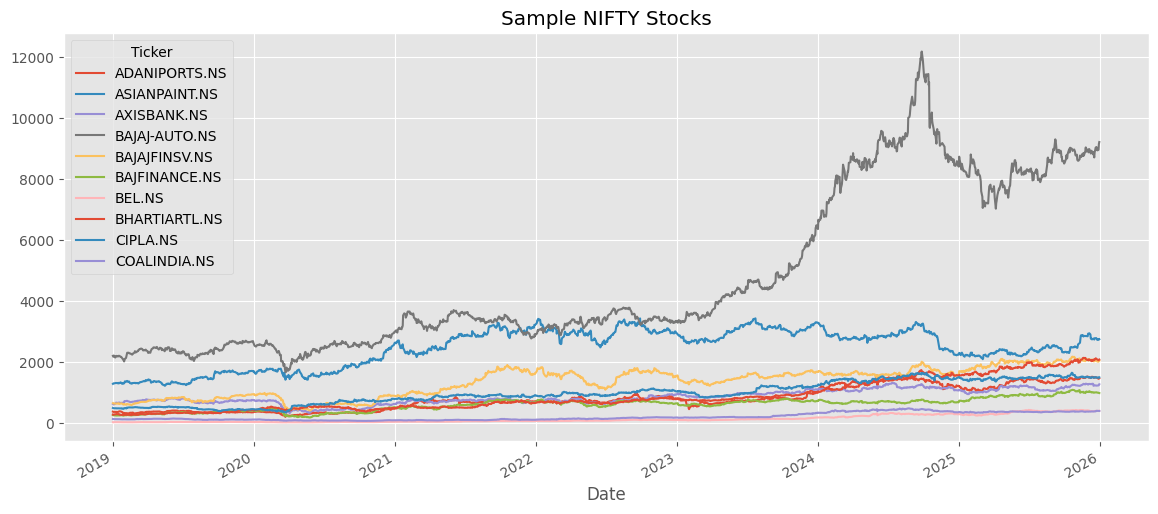


Dataset Ready for Rolling Backtest


In [14]:
# ==========================================================
# Robust Portfolio Optimization using CVXPY
# Part 1 : NIFTY 50 Data Collection
# ==========================================================

# Install (Run Once)
!pip install yfinance cvxpy --quiet

# ==========================================================
# Import Libraries
# ==========================================================

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp

plt.style.use("ggplot")

# ==========================================================
# NIFTY 50 Stocks
# ==========================================================

stocks = [

"ADANIPORTS.NS",
"ASIANPAINT.NS",
"AXISBANK.NS",
"BAJAJ-AUTO.NS",
"BAJFINANCE.NS",
"BAJAJFINSV.NS",
"BEL.NS",
"BHARTIARTL.NS",
"CIPLA.NS",
"COALINDIA.NS",
"DRREDDY.NS",
"EICHERMOT.NS",
"ETERNAL.NS",
"GRASIM.NS",
"HCLTECH.NS",
"HDFCBANK.NS",
"HDFCLIFE.NS",
"HEROMOTOCO.NS",
"HINDALCO.NS",
"HINDUNILVR.NS",
"ICICIBANK.NS",
"INDUSINDBK.NS",
"INFY.NS",
"ITC.NS",
"JIOFIN.NS",
"JSWSTEEL.NS",
"KOTAKBANK.NS",
"LT.NS",
"M&M.NS",
"MARUTI.NS",
"NESTLEIND.NS",
"NTPC.NS",
"ONGC.NS",
"POWERGRID.NS",
"RELIANCE.NS",
"SBILIFE.NS",
"SBIN.NS",
"SHRIRAMFIN.NS",
"SUNPHARMA.NS",
"TATACONSUM.NS",
"TATAMOTORS.NS",
"TATASTEEL.NS",
"TCS.NS",
"TECHM.NS",
"TITAN.NS",
"TRENT.NS",
"ULTRACEMCO.NS",
"WIPRO.NS"

]

# ==========================================================
# Download Data
# ==========================================================

prices = yf.download(

stocks,
start="2019-01-01",
end="2026-01-01",
auto_adjust=True,
progress=False

)["Close"]

# ==========================================================
# Clean Data
# ==========================================================

prices = prices.dropna(axis=1)

prices = prices.dropna()

print("Assets:", prices.shape[1])

print("Trading Days:", prices.shape[0])

# ==========================================================
# Daily Returns
# ==========================================================

returns = prices.pct_change().dropna()

# ==========================================================
# Annualized Mean Return
# ==========================================================

mu = returns.mean()*252

# ==========================================================
# Annualized Covariance
# ==========================================================

Sigma = returns.cov()*252

print("\nExpected Annual Returns")

print(mu.round(4))

print("\nCovariance Matrix Shape")

print(Sigma.shape)

# ==========================================================
# Missing Values
# ==========================================================

print("\nMissing Values")

print(returns.isna().sum().sum())

# ==========================================================
# Correlation Matrix
# ==========================================================

corr = returns.corr()

plt.figure(figsize=(12,10))

plt.imshow(corr,cmap="coolwarm")

plt.colorbar()

plt.xticks(
range(len(corr.columns)),
corr.columns,
rotation=90,
fontsize=7
)

plt.yticks(
range(len(corr.columns)),
corr.columns,
fontsize=7
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

# ==========================================================
# Price Chart
# ==========================================================

prices.iloc[:,0:10].plot(figsize=(14,6))

plt.title("Sample NIFTY Stocks")

plt.grid(True)

plt.show()

# ==========================================================
# Save Data
# ==========================================================

returns.to_csv("NIFTY50_Returns.csv")

prices.to_csv("NIFTY50_Prices.csv")

print("\nDataset Ready for Rolling Backtest")

In [15]:
# ==========================================================
# Part 2 : Rolling Window Engine
# ==========================================================

# Training Window (1 Year)
train_window = 252

# Rebalance Frequency (Monthly)
rebalance = 21

# Containers
dates = []

markowitz_returns = []

box_returns = []

elliptical_returns = []

markowitz_weights = []

box_weights = []

elliptical_weights = []

print("="*60)
print("Rolling Backtest Started")
print("="*60)

# ----------------------------------------------------------
# Rolling Window Loop
# ----------------------------------------------------------

for start in range(
    0,
    len(returns)-train_window-rebalance+1,
    rebalance
):

    # ------------------------------------------------------
    # Training Dataset
    # ------------------------------------------------------

    train = returns.iloc[
        start:start+train_window
    ]

    # ------------------------------------------------------
    # Test Dataset
    # ------------------------------------------------------

    test = returns.iloc[
        start+train_window:
        start+train_window+rebalance
    ]

    # ------------------------------------------------------
    # Statistics
    # ------------------------------------------------------

    mu_train = train.mean()*252

    Sigma_train = train.cov()*252

    # ------------------------------------------------------
    # Save Test Dates
    # ------------------------------------------------------

    dates.extend(test.index)

    # ------------------------------------------------------
    # Progress
    # ------------------------------------------------------

    print(
        f"Window {start//rebalance+1:02d} | "
        f"Train: {train.index[0].date()} -> {train.index[-1].date()} | "
        f"Test: {test.index[0].date()} -> {test.index[-1].date()}"
    )

print("\nRolling Windows Created Successfully!")
print(f"Total Rebalancing Periods : {len(dates)//rebalance}")

Rolling Backtest Started
Window 01 | Train: 2019-01-02 -> 2020-01-14 | Test: 2020-01-15 -> 2020-02-12
Window 02 | Train: 2019-01-31 -> 2020-02-12 | Test: 2020-02-13 -> 2020-03-16
Window 03 | Train: 2019-03-05 -> 2020-03-16 | Test: 2020-03-17 -> 2020-04-20
Window 04 | Train: 2019-04-05 -> 2020-04-20 | Test: 2020-04-21 -> 2020-05-20
Window 05 | Train: 2019-05-10 -> 2020-05-20 | Test: 2020-05-21 -> 2020-06-19
Window 06 | Train: 2019-06-11 -> 2020-06-19 | Test: 2020-06-22 -> 2020-07-20
Window 07 | Train: 2019-07-10 -> 2020-07-20 | Test: 2020-07-21 -> 2020-08-18
Window 08 | Train: 2019-08-08 -> 2020-08-18 | Test: 2020-08-19 -> 2020-09-16
Window 09 | Train: 2019-09-12 -> 2020-09-16 | Test: 2020-09-17 -> 2020-10-16
Window 10 | Train: 2019-10-15 -> 2020-10-16 | Test: 2020-10-19 -> 2020-11-14
Window 11 | Train: 2019-11-15 -> 2020-11-14 | Test: 2020-11-17 -> 2020-12-16
Window 12 | Train: 2019-12-16 -> 2020-12-16 | Test: 2020-12-17 -> 2021-01-15
Window 13 | Train: 2020-01-15 -> 2021-01-15 | Test:

In [16]:
print(train.head())

print()

print(test.head())

print()

print(mu_train.head())

print()

print(Sigma_train.iloc[:5,:5])

Ticker      ADANIPORTS.NS  ASIANPAINT.NS  AXISBANK.NS  BAJAJ-AUTO.NS  \
Date                                                                   
2024-11-14      -0.018130       0.005120     0.001361       0.003259   
2024-11-18       0.011664       0.000221    -0.012712       0.003538   
2024-11-19       0.008090       0.001714     0.006882       0.003068   
2024-11-21      -0.135696      -0.022366     0.004586      -0.004264   
2024-11-22       0.019827       0.018141     0.002853      -0.002457   

Ticker      BAJAJFINSV.NS  BAJFINANCE.NS    BEL.NS  BHARTIARTL.NS  CIPLA.NS  \
Date                                                                          
2024-11-14      -0.014810      -0.002566 -0.002131       0.000032 -0.003886   
2024-11-18      -0.014514       0.002871 -0.010322      -0.008707 -0.023004   
2024-11-19      -0.012160       0.004164  0.003417      -0.007482  0.004300   
2024-11-21      -0.016976      -0.019658 -0.012724      -0.000229 -0.004111   
2024-11-22       0.02

In [21]:
# ==========================================================
# Part 3 : Rolling Markowitz Optimization
# ==========================================================

gamma = 5

# Reset containers
dates = []
markowitz_returns = []
markowitz_weights = []

for start in range(0, len(returns) - train_window - rebalance + 1, rebalance):

    # -------------------------------
    # Train/Test Split
    # -------------------------------
    train = returns.iloc[start:start + train_window]

    test = returns.iloc[start + train_window:
                        start + train_window + rebalance]

    # -------------------------------
    # Annualized Statistics
    # -------------------------------
    mu = train.mean() * 252
    Sigma = train.cov() * 252

    n = len(mu)

    # -------------------------------
    # CVXPY Variable
    # -------------------------------
    w = cp.Variable(n)

    objective = cp.Maximize(
        mu.values @ w -
        gamma * cp.quad_form(w, Sigma.values)
    )

    constraints = [
        cp.sum(w) == 1,
        w >= 0
    ]

    problem = cp.Problem(objective, constraints)

    problem.solve(solver=cp.SCS)

    # Skip failed optimization
    if w.value is None:
        continue

    weights = np.array(w.value).flatten()

    # Normalize weights
    weights = weights / weights.sum()

    markowitz_weights.append(weights)

    # -------------------------------
    # Out-of-Sample Portfolio Returns
    # -------------------------------
    portfolio_returns = test.values @ weights

    markowitz_returns.extend(portfolio_returns)

    dates.extend(test.index)

print("Rolling Backtest Completed!")

Rolling Backtest Completed!


In [22]:
# ==========================================
# Performance Metrics
# ==========================================

markowitz_returns = pd.Series(
    markowitz_returns,
    index=dates
)

equity = (1 + markowitz_returns).cumprod()

years = len(markowitz_returns) / 252

cagr = equity.iloc[-1] ** (1 / years) - 1

annual_vol = markowitz_returns.std() * np.sqrt(252)

sharpe = cagr / annual_vol

max_drawdown = (equity / equity.cummax() - 1).min()

print("=" * 50)
print("Rolling Markowitz Performance")
print("=" * 50)

print(f"CAGR              : {cagr:.2%}")
print(f"Annual Volatility : {annual_vol:.2%}")
print(f"Sharpe Ratio      : {sharpe:.4f}")
print(f"Maximum Drawdown  : {max_drawdown:.2%}")

Rolling Markowitz Performance
CAGR              : 24.92%
Annual Volatility : 23.20%
Sharpe Ratio      : 1.0742
Maximum Drawdown  : -36.07%


In [23]:
# ==========================================================
# Part 4 : Rolling Box Robust Optimization
# ==========================================================

gamma = 5
delta = 0.05      # 5% uncertainty in expected returns

box_returns = []
box_weights = []

for start in range(0, len(returns)-train_window-rebalance+1, rebalance):

    # -----------------------------
    # Train/Test Split
    # -----------------------------
    train = returns.iloc[start:start+train_window]

    test = returns.iloc[start+train_window:
                        start+train_window+rebalance]

    # -----------------------------
    # Statistics
    # -----------------------------
    mu = train.mean()*252
    Sigma = train.cov()*252

    # Worst-case expected returns
    mu_box = mu.values - delta*np.abs(mu.values)

    n = len(mu)

    # -----------------------------
    # CVXPY Variable
    # -----------------------------
    w = cp.Variable(n)

    objective = cp.Maximize(
        mu_box @ w
        -
        gamma*cp.quad_form(w, Sigma.values)
    )

    constraints = [
        cp.sum(w) == 1,
        w >= 0
    ]

    problem = cp.Problem(objective, constraints)

    problem.solve(solver=cp.SCS)

    if w.value is None:
        continue

    weights = np.array(w.value).flatten()
    weights = weights / weights.sum()

    box_weights.append(weights)

    portfolio_returns = test.values @ weights

    box_returns.extend(portfolio_returns)

print("Rolling Box Robust Completed")

Rolling Box Robust Completed


In [24]:
box_returns = pd.Series(
    box_returns,
    index=dates
)

box_equity = (1 + box_returns).cumprod()

years = len(box_returns)/252

box_cagr = box_equity.iloc[-1]**(1/years)-1

box_vol = box_returns.std()*np.sqrt(252)

box_sharpe = box_cagr/box_vol

box_dd = (
    box_equity/
    box_equity.cummax()-1
).min()

print("="*50)
print("Rolling Box Robust Performance")
print("="*50)

print(f"CAGR              : {box_cagr:.2%}")
print(f"Annual Volatility : {box_vol:.2%}")
print(f"Sharpe Ratio      : {box_sharpe:.4f}")
print(f"Maximum Drawdown  : {box_dd:.2%}")

Rolling Box Robust Performance
CAGR              : 24.90%
Annual Volatility : 23.01%
Sharpe Ratio      : 1.0825
Maximum Drawdown  : -36.00%


In [25]:
# ==========================================================
# Part 5 : Rolling Elliptical Robust Optimization
# ==========================================================

import scipy.linalg

gamma = 5
kappa = 0.30        # Uncertainty aversion parameter

elliptical_returns = []
elliptical_weights = []

for start in range(0, len(returns)-train_window-rebalance+1, rebalance):

    # -------------------------------------------------
    # Train/Test Split
    # -------------------------------------------------

    train = returns.iloc[start:start+train_window]

    test = returns.iloc[start+train_window:
                        start+train_window+rebalance]

    # -------------------------------------------------
    # Annualized Statistics
    # -------------------------------------------------

    mu = train.mean()*252

    Sigma = train.cov()*252

    n = len(mu)

    Sigma_sqrt = scipy.linalg.sqrtm(Sigma.values)

    # -------------------------------------------------
    # Optimization Variable
    # -------------------------------------------------

    w = cp.Variable(n)

    portfolio_return = mu.values @ w

    portfolio_risk = cp.quad_form(w, Sigma.values)

    uncertainty_penalty = kappa * cp.norm(
        Sigma_sqrt @ w,
        2
    )

    objective = cp.Maximize(

        portfolio_return

        - uncertainty_penalty

        - gamma*portfolio_risk

    )

    constraints = [

        cp.sum(w)==1,

        w>=0

    ]

    problem = cp.Problem(objective, constraints)

    problem.solve(solver=cp.SCS)

    if w.value is None:
        continue

    weights = np.array(w.value).flatten()

    weights = weights/weights.sum()

    elliptical_weights.append(weights)

    portfolio_returns = test.values @ weights

    elliptical_returns.extend(portfolio_returns)

print("Rolling Elliptical Robust Completed")

Rolling Elliptical Robust Completed


In [26]:
elliptical_returns = pd.Series(
    elliptical_returns,
    index=dates
)

elliptical_equity = (1+elliptical_returns).cumprod()

years = len(elliptical_returns)/252

elliptical_cagr = (
    elliptical_equity.iloc[-1]**(1/years)-1
)

elliptical_vol = (
    elliptical_returns.std()*np.sqrt(252)
)

elliptical_sharpe = (
    elliptical_cagr/elliptical_vol
)

elliptical_dd = (
    elliptical_equity/
    elliptical_equity.cummax()-1
).min()

print("="*50)
print("Rolling Elliptical Performance")
print("="*50)

print(f"CAGR              : {elliptical_cagr:.2%}")
print(f"Annual Volatility : {elliptical_vol:.2%}")
print(f"Sharpe Ratio      : {elliptical_sharpe:.4f}")
print(f"Maximum Drawdown  : {elliptical_dd:.2%}")

Rolling Elliptical Performance
CAGR              : 24.56%
Annual Volatility : 22.68%
Sharpe Ratio      : 1.0832
Maximum Drawdown  : -35.85%


In [27]:
results = pd.DataFrame({

    "Model":[
        "Markowitz",
        "Box Robust",
        "Elliptical Robust"
    ],

    "CAGR":[
        cagr,
        box_cagr,
        elliptical_cagr
    ],

    "Volatility":[
        annual_vol,
        box_vol,
        elliptical_vol
    ],

    "Sharpe":[
        sharpe,
        box_sharpe,
        elliptical_sharpe
    ],

    "Max Drawdown":[
        max_drawdown,
        box_dd,
        elliptical_dd
    ]

})

print(results.round(4))

               Model    CAGR  Volatility  Sharpe  Max Drawdown
0          Markowitz  0.2492      0.2320  1.0742       -0.3607
1         Box Robust  0.2490      0.2301  1.0825       -0.3600
2  Elliptical Robust  0.2456      0.2268  1.0832       -0.3585
